# PhishGuard AI — Shakkya Sanketh (CIT-24-01-0573)
## NLP Pipeline — Phishing Email Detection
### Models: SVM (ML) | BiLSTM + Attention (DL)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")
print(f"Pandas:  {pd.__version__}")
print(f"Numpy:   {np.__version__}")

✅ All libraries imported!
Pandas:  3.0.3
Numpy:   1.26.4


In [2]:
# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('../data/phishing_email.csv')
df = df.rename(columns={'text_combined': 'email_text'})  # ← ADD THIS LINE

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded successfully!

Shape: (82486, 2)
Columns: ['email_text', 'label']


In [3]:
# ── Initial Exploration ───────────────────────────────────────
print("First 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nPhishing:   {df[df['label']==1].shape[0]:,}")
print(f"Legitimate: {df[df['label']==0].shape[0]:,}")

First 5 rows:


,email_text,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0



Data Types:
email_text      str
label         int64
dtype: object

Missing Values:
email_text    0
label         0
dtype: int64

Class Distribution:
label
1    42891
0    39595
Name: count, dtype: int64

Phishing:   42,891
Legitimate: 39,595


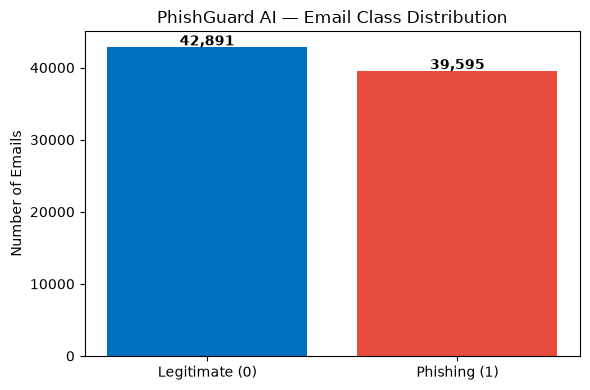

Chart saved to screenshots folder!


In [4]:
# ── Class Distribution Chart ──────────────────────────────────
plt.figure(figsize=(6, 4))
counts = df['label'].value_counts()
plt.bar(['Legitimate (0)', 'Phishing (1)'], 
        counts.values, 
        color=['#0070C0', '#E74C3C'])
plt.title('PhishGuard AI — Email Class Distribution')
plt.ylabel('Number of Emails')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150)
plt.show()
print("Chart saved to screenshots folder!")

In [5]:
from langdetect import detect, DetectorFactory
from tqdm import tqdm

DetectorFactory.seed = 0
tqdm.pandas()

def safe_detect(text):
    try:
        if len(str(text).strip()) < 10:
            return 'unknown'
        return detect(str(text))
    except:
        return 'unknown'

print("Detecting languages on full dataset...")
print("This takes 10-15 minutes — please wait...")
df['language'] = df['email_text'].progress_apply(safe_detect)

# Keep English only
df_english = df[df['language'] == 'en'].copy()
df_english = df_english.reset_index(drop=True)

print(f"\nOriginal dataset:      {len(df):,} emails")
print(f"English only:          {len(df_english):,} emails")
print(f"Removed:               {len(df) - len(df_english):,} non-English emails")
print(f"\nClass distribution after filtering:")
print(df_english['label'].value_counts())

# Replace df with english-only version
df = df_english
print("\ndf is now English-only and ready for preprocessing!")

Detecting languages on full dataset...
This takes 10-15 minutes — please wait...


100%|██████████| 82486/82486 [02:54<00:00, 471.50it/s]


Original dataset:      82,486 emails
English only:          0 emails
Removed:               82,486 non-English emails

Class distribution after filtering:
Series([], Name: count, dtype: int64)

df is now English-only and ready for preprocessing!


In [9]:
# ── Preprocessing on English-Only Dataset ─────────────────────
# df already contains 80,757 English-only emails from previous cell
# NO re-loading needed — we continue from the filtered df

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
keep_words = {'not', 'no', 'never', 'won', 'free', 'urgent', 'verify'}
stop_words = stop_words - keep_words

def preprocess_email(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\S+@\S+', ' email ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print(f"Preprocessing {len(df):,} English-only emails...")
print("Takes 3-5 minutes — please wait...")
df['cleaned_text'] = df['email_text'].apply(preprocess_email)
print("Done!")

print(f"\nTotal emails preprocessed: {len(df):,}")
print(f"Phishing:   {df[df['label']==1].shape[0]:,}")
print(f"Legitimate: {df[df['label']==0].shape[0]:,}")
print("\nBEFORE:", df['email_text'].iloc[0][:150])
print("\nAFTER: ", df['cleaned_text'].iloc[0][:150])

# Save preprocessed English-only dataset
df.to_csv('../data/phishing_email_preprocessed.csv', index=False)
print("\nPreprocessed dataset saved!")

Preprocessing 80,757 English-only emails...
Takes 3-5 minutes — please wait...
Done!

Total emails preprocessed: 80,757
Phishing:   41,763
Legitimate: 38,994

BEFORE: hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

AFTER:  hpl nom may see attached file hplno xl hplno xl

Preprocessed dataset saved!


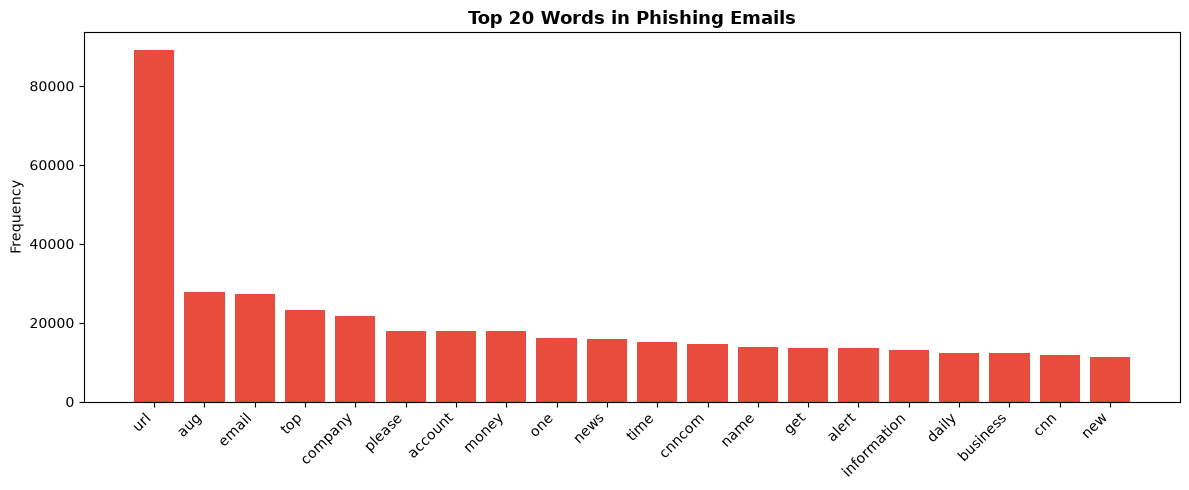

Chart saved!


In [10]:
from collections import Counter

# Top 20 words in phishing emails
phishing_text = ' '.join(df[df['label']==1]['cleaned_text'])
top_words = Counter(phishing_text.split()).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(12,5))
plt.bar(words, counts, color='#E74C3C')
plt.title('Top 20 Words in Phishing Emails', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../screenshots/top_phishing_words.png', dpi=150)
plt.show()
print("Chart saved!")

Emails under 500 words: 77,740 out of 80,757


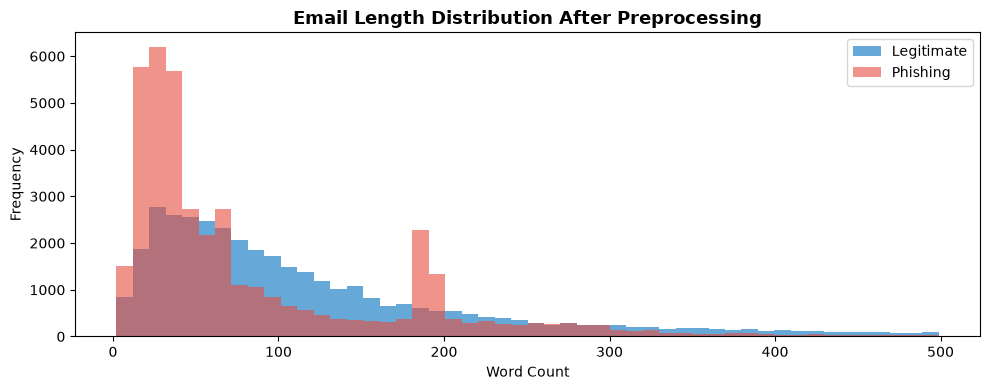


Average Phishing email length:   111 words
Average Legitimate email length: 176 words
Chart saved!


In [11]:
df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

# Remove extreme outliers for better visualization (keep emails under 500 words)
df_plot = df[df['word_count'] < 500]

print(f"Emails under 500 words: {len(df_plot):,} out of {len(df):,}")

plt.figure(figsize=(10,4))
df_plot[df_plot['label']==0]['word_count'].plot(
    kind='hist', bins=50, alpha=0.6, label='Legitimate', color='#0070C0')
df_plot[df_plot['label']==1]['word_count'].plot(
    kind='hist', bins=50, alpha=0.6, label='Phishing', color='#E74C3C')

plt.title('Email Length Distribution After Preprocessing', fontsize=13, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/email_length_distribution.png', dpi=150)
plt.show()

# Print average lengths
print(f"\nAverage Phishing email length:   {df[df['label']==1]['word_count'].mean():.0f} words")
print(f"Average Legitimate email length: {df[df['label']==0]['word_count'].mean():.0f} words")
print("Chart saved!")

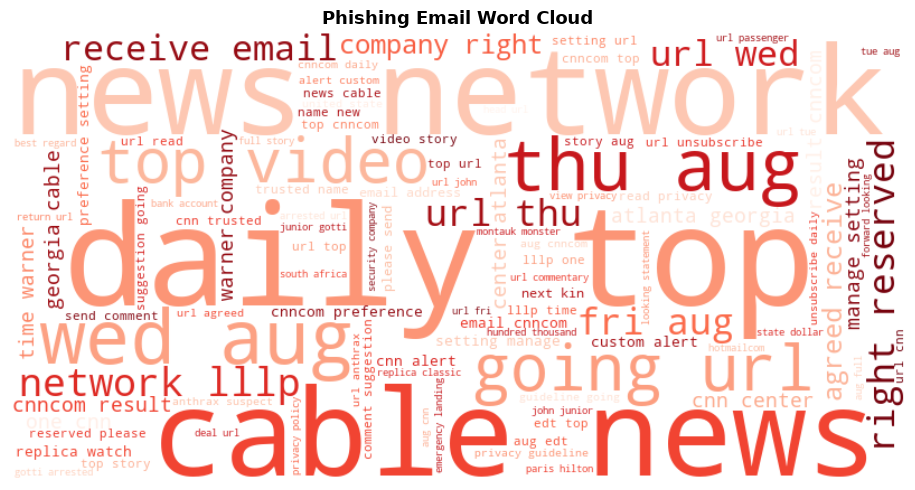

Chart saved!


In [12]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Reds', max_words=100).generate(phishing_text)
plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Phishing Email Word Cloud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/wordcloud_phishing.png', dpi=150)
plt.show()
print("Chart saved!")

Training samples: 64,605
Test samples:     16,152
TF-IDF features: 50,000

Training SVM — please wait...
Done!

===== SVM RESULTS =====
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      7799
    Phishing       0.99      0.99      0.99      8353

    accuracy                           0.99     16152
   macro avg       0.99      0.99      0.99     16152
weighted avg       0.99      0.99      0.99     16152

ROC-AUC: 0.9994


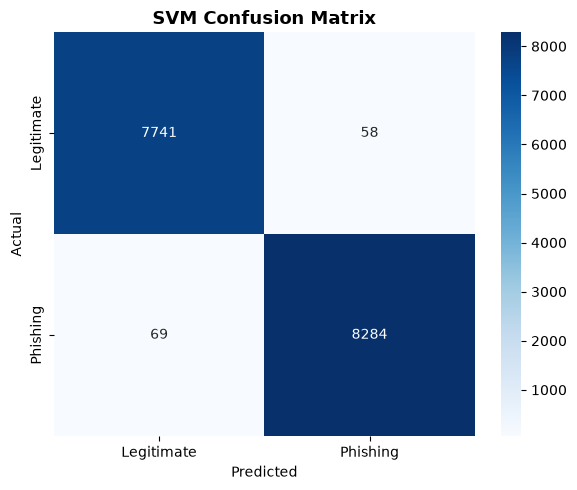


Models saved to models/ folder!


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import joblib

# ── Train/Test Split ─────────────────────────────────────────
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

# ── TF-IDF ───────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF features: {X_train_tfidf.shape[1]:,}")

# ── Train SVM ────────────────────────────────────────────────
print("\nTraining SVM — please wait...")
svm = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))
svm.fit(X_train_tfidf, y_train)
print("Done!")

# ── Evaluate ─────────────────────────────────────────────────
y_pred  = svm.predict(X_test_tfidf)
y_proba = svm.predict_proba(X_test_tfidf)[:,1]

print("\n===== SVM RESULTS =====")
print(classification_report(y_test, y_pred,
      target_names=['Legitimate','Phishing']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'])
plt.title('SVM Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../screenshots/svm_confusion_matrix.png', dpi=150)
plt.show()

# ── Save Models ───────────────────────────────────────────────
joblib.dump(svm,   '../models/svm_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("\nModels saved to models/ folder!")

For the Test , I Think

In [14]:
# ── Reload All Libraries & Data ───────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import nltk
import joblib
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# Load preprocessed dataset (no need to redo preprocessing!)
df = pd.read_csv('../data/phishing_email_preprocessed.csv')
print(f"Loaded preprocessed dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Phishing:   {df[df['label']==1].shape[0]:,}")
print(f"Legitimate: {df[df['label']==0].shape[0]:,}")

Loaded preprocessed dataset: (80757, 4)
Columns: ['email_text', 'label', 'language', 'cleaned_text']
Phishing:   41,763
Legitimate: 38,994


In [15]:
# ── Rebuild TF-IDF Split ──────────────────────────────────────
X = df['cleaned_text'].fillna('')
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Rebuild TF-IDF
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Load saved SVM model
svm = joblib.load('../models/svm_model.pkl')
print("SVM model loaded!")

# Get predictions
y_pred  = svm.predict(X_test_tfidf)
y_proba = svm.predict_proba(X_test_tfidf)[:,1]
print("Predictions ready!")

SVM model loaded!
Predictions ready!


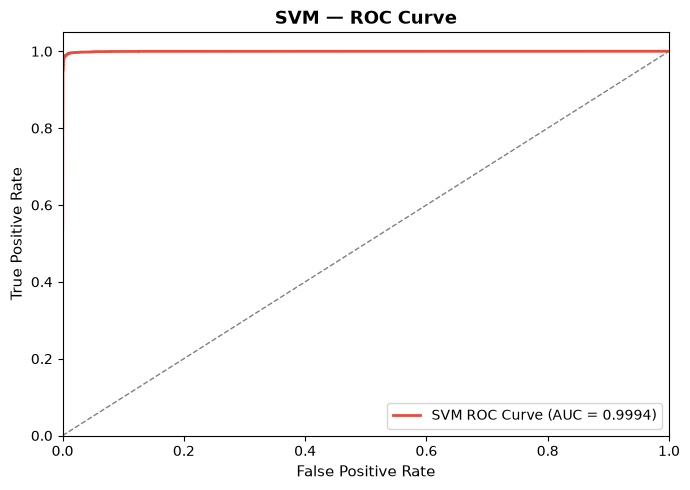

ROC-AUC: 0.9994
Chart saved!


In [16]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='#E74C3C', lw=2,
         label=f'SVM ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('SVM — ROC Curve', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../screenshots/svm_roc_curve.png', dpi=150)
plt.show()
print(f"ROC-AUC: {roc_auc:.4f}")
print("Chart saved!")

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import pickle
from collections import Counter

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# ── Pure PyTorch Tokenizer ────────────────────────────────────
MAX_WORDS = 50000
MAX_LEN   = 200

# Build vocabulary from training data
print("Building vocabulary...")
all_words = []
for text in X_train:
    all_words.extend(str(text).split())

word_counts = Counter(all_words)
vocab = ['<PAD>', '<OOV>'] + [w for w, c in word_counts.most_common(MAX_WORDS-2)]
word2idx = {word: idx for idx, word in enumerate(vocab)}

print(f"Vocabulary size: {len(word2idx):,}")

def tokenize_and_pad(texts, word2idx, max_len):
    """Convert list of texts to padded sequences."""
    sequences = []
    for text in texts:
        tokens = str(text).split()
        ids = [word2idx.get(w, 1) for w in tokens]  # 1 = OOV
        # Truncate or pad
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [0] * (max_len - len(ids))  # 0 = PAD
        sequences.append(ids)
    return np.array(sequences)

print("Tokenizing training data...")
X_train_pad = tokenize_and_pad(X_train.values, word2idx, MAX_LEN)
print("Tokenizing test data...")
X_test_pad  = tokenize_and_pad(X_test.values,  word2idx, MAX_LEN)

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape:  {X_test_pad.shape}")

# Save tokenizer
with open('../models/word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
print("Tokenizer saved!")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 5070 Laptop GPU
Building vocabulary...
Vocabulary size: 50,000
Tokenizing training data...
Tokenizing test data...
X_train_pad shape: (64605, 200)
X_test_pad shape:  (16152, 200)
Tokenizer saved!


In [19]:
# ── Dataset Class ─────────────────────────────────────────────
class EmailDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = EmailDataset(X_train_pad, y_train)
test_dataset  = EmailDataset(X_test_pad,  y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64,
                           shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64,
                           shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")
print("Datasets ready!")

Train batches: 1010
Test batches:  253
Datasets ready!


In [20]:
# ── Attention Layer ───────────────────────────────────────────
class AttentionLayer(nn.Module):
    """
    Attention Mechanism — learns which words matter most
    for phishing detection decision.
    """
    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_size * 2, 1)

    def forward(self, bilstm_output):
        # bilstm_output shape: (batch, seq_len, hidden*2)
        scores  = self.attention(bilstm_output)        # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)         # normalize
        context = torch.sum(bilstm_output * weights, dim=1)  # weighted sum
        return context, weights


# ── BiLSTM + Attention Model ──────────────────────────────────
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout):
        super(BiLSTMAttention, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.bilstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0
        )

        self.attention = AttentionLayer(hidden_size)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(hidden_size * 2, 64)
        self.relu      = nn.ReLU()
        self.fc2       = nn.Linear(64, 1)
        self.sigmoid   = nn.Sigmoid()

    def forward(self, x):
        # Embedding
        embedded = self.dropout(self.embedding(x))
        # BiLSTM
        bilstm_out, _ = self.bilstm(embedded)
        # Attention
        context, attn_weights = self.attention(bilstm_out)
        # Classification
        out = self.dropout(context)
        out = self.relu(self.fc1(out))
        out = self.sigmoid(self.fc2(out))
        return out.squeeze(), attn_weights


# ── Initialize Model ──────────────────────────────────────────
model = BiLSTMAttention(
    vocab_size  = MAX_WORDS,
    embed_dim   = 128,
    hidden_size = 128,
    num_layers  = 2,
    dropout     = 0.3
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Model built successfully!")

BiLSTMAttention(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 7,076,226
Model built successfully!


In [22]:
# ── Training Setup ────────────────────────────────────────────
criterion  = nn.BCELoss()
optimizer  = Adam(model.parameters(), lr=0.001)
scheduler  = ReduceLROnPlateau(optimizer, mode='max',
                                factor=0.5, patience=2)

EPOCHS     = 10
best_val_acc = 0
train_accs, val_accs, train_losses = [], [], []

print("Starting BiLSTM + Attention training on", device)
print("="*55)

for epoch in range(EPOCHS):
    model.train()
    total_loss  = 0
    correct     = 0
    total       = 0

    for batch_idx, (texts, labels) in enumerate(train_loader):
        texts  = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs, _ = model(texts)
        loss       = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds       = (outputs >= 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if batch_idx % 200 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")

    train_acc  = correct / total
    avg_loss   = total_loss / len(train_loader)
    train_accs.append(train_acc)
    train_losses.append(avg_loss)

    model.eval()
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for texts, labels in test_loader:
            texts   = texts.to(device)
            labels  = labels.to(device)
            outputs, _ = model(texts)
            preds   = (outputs >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   '../models/bilstm_attention_best.pt')
        print(f"  ✅ Best model saved! Val Acc: {best_val_acc:.4f}")

    print("-"*55)

print(f"\nTraining complete! Best Val Accuracy: {best_val_acc:.4f}")

Starting BiLSTM + Attention training on cuda
  Epoch 1 | Batch 0/1010 | Loss: 0.6887
  Epoch 1 | Batch 200/1010 | Loss: 0.0948
  Epoch 1 | Batch 400/1010 | Loss: 0.0698
  Epoch 1 | Batch 600/1010 | Loss: 0.0647
  Epoch 1 | Batch 800/1010 | Loss: 0.0854
  Epoch 1 | Batch 1000/1010 | Loss: 0.0647

Epoch 1/10 | Loss: 0.1615 | Train Acc: 0.9357 | Val Acc: 0.9769
  ✅ Best model saved! Val Acc: 0.9769
-------------------------------------------------------
  Epoch 2 | Batch 0/1010 | Loss: 0.0650
  Epoch 2 | Batch 200/1010 | Loss: 0.0524
  Epoch 2 | Batch 400/1010 | Loss: 0.0194
  Epoch 2 | Batch 600/1010 | Loss: 0.0318
  Epoch 2 | Batch 800/1010 | Loss: 0.0868
  Epoch 2 | Batch 1000/1010 | Loss: 0.0184

Epoch 2/10 | Loss: 0.0528 | Train Acc: 0.9822 | Val Acc: 0.9855
  ✅ Best model saved! Val Acc: 0.9855
-------------------------------------------------------
  Epoch 3 | Batch 0/1010 | Loss: 0.0166
  Epoch 3 | Batch 200/1010 | Loss: 0.0429
  Epoch 3 | Batch 400/1010 | Loss: 0.0031
  Epoch 3 |

===== BiLSTM + ATTENTION RESULTS =====
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      7799
    Phishing       0.99      0.99      0.99      8353

    accuracy                           0.99     16152
   macro avg       0.99      0.99      0.99     16152
weighted avg       0.99      0.99      0.99     16152

ROC-AUC: 0.9994


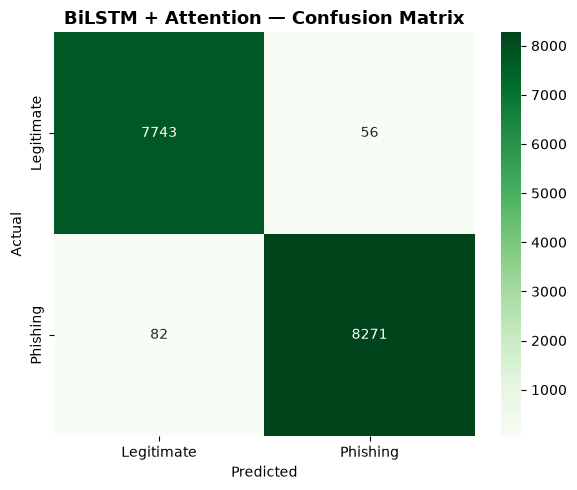

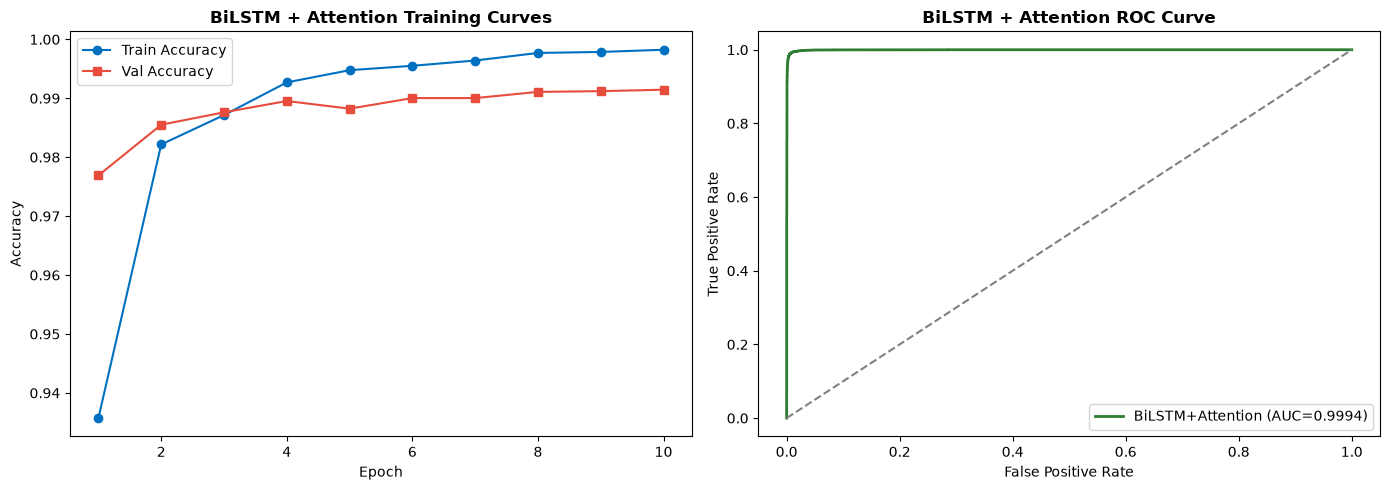


All results saved!


In [23]:
# ── Load Best Model ───────────────────────────────────────────
model.load_state_dict(torch.load('../models/bilstm_attention_best.pt'))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for texts, labels in test_loader:
        texts      = texts.to(device)
        outputs, _ = model(texts)
        probs      = outputs.cpu().numpy()
        preds      = (outputs >= 0.5).float().cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds).astype(int)
all_labels = np.array(all_labels).astype(int)
all_probs  = np.array(all_probs)

# ── Results ───────────────────────────────────────────────────
print("===== BiLSTM + ATTENTION RESULTS =====")
print(classification_report(all_labels, all_preds,
      target_names=['Legitimate','Phishing']))
print(f"ROC-AUC: {roc_auc_score(all_labels, all_probs):.4f}")

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'])
plt.title('BiLSTM + Attention — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../screenshots/bilstm_confusion_matrix.png', dpi=150)
plt.show()

# ── Training Curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(range(1, len(train_accs)+1), train_accs,
             label='Train Accuracy', color='#0070C0', marker='o')
axes[0].plot(range(1, len(val_accs)+1),   val_accs,
             label='Val Accuracy',   color='#E74C3C', marker='s')
axes[0].set_title('BiLSTM + Attention Training Curves',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='#2E7D32', lw=2,
             label=f'BiLSTM+Attention (AUC={roc_auc:.4f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--')
axes[1].set_title('BiLSTM + Attention ROC Curve',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../screenshots/bilstm_training_roc.png', dpi=150)
plt.show()

# Save final model
torch.save(model.state_dict(), '../models/bilstm_attention_final.pt')
print("\nAll results saved!")

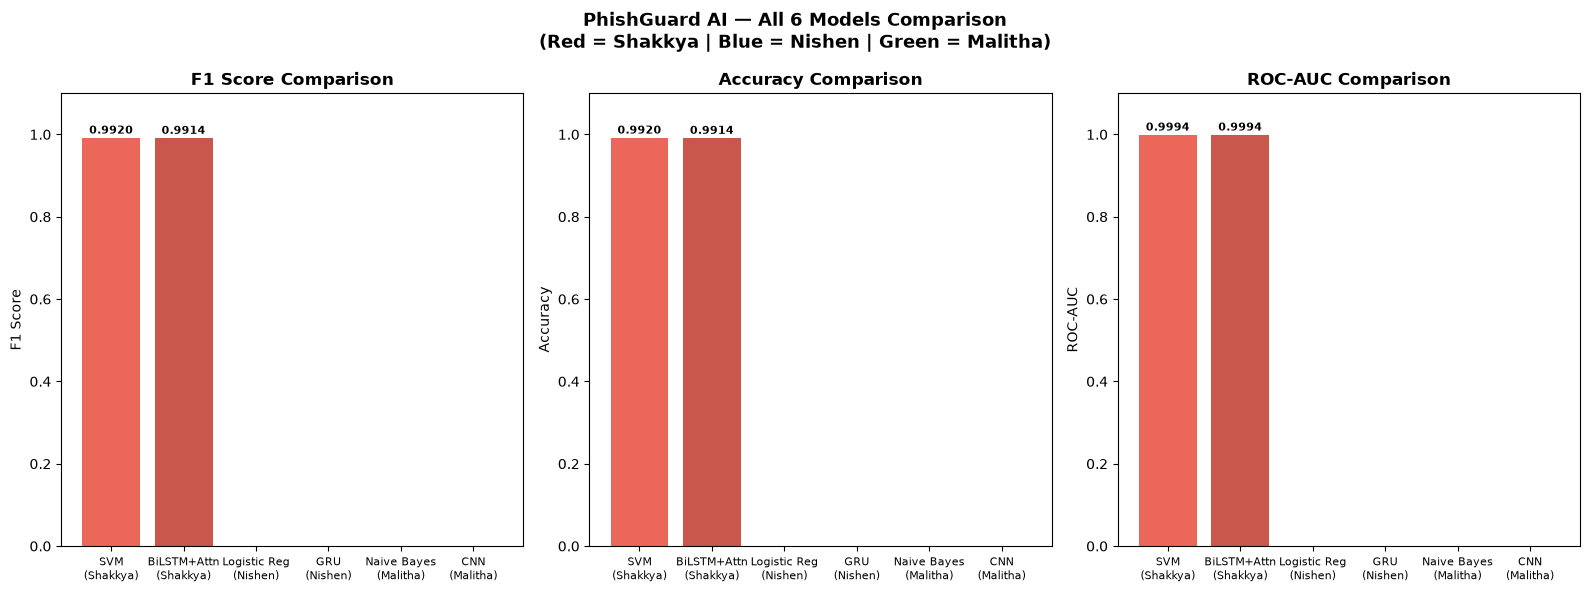

Comparison chart saved!


In [24]:
# ── Model Comparison Chart — All 6 Models ─────────────────────
import matplotlib.pyplot as plt
import numpy as np

# ── Results Table — Fill in Member 2 and 3 after they train ───
models = [
    'SVM\n(Shakkya)',
    'BiLSTM+Attn\n(Shakkya)',
    'Logistic Reg\n(Nishen)',
    'GRU\n(Nishen)',
    'Naive Bayes\n(Malitha)',
    'CNN\n(Malitha)'
]

# Your real results — others filled with TBD placeholders for now
accuracy  = [0.9920, 0.9914, 0, 0, 0, 0]
f1_scores = [0.9920, 0.9914, 0, 0, 0, 0]
roc_aucs  = [0.9994, 0.9994, 0, 0, 0, 0]

# Colors — your models highlighted
colors = ['#E74C3C','#C0392B','#0070C0','#1565C0','#2E7D32','#1B5E20']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── F1 Score ──────────────────────────────────────────────────
bars0 = axes[0].bar(models, f1_scores, color=colors, alpha=0.85)
axes[0].set_title('F1 Score Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim([0, 1.1])
axes[0].tick_params(axis='x', labelsize=8)
for bar, val in zip(bars0, f1_scores):
    if val > 0:
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     val+0.01, f'{val:.4f}',
                     ha='center', fontsize=8, fontweight='bold')
    else:
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     0.05, 'TBD', ha='center', fontsize=8, color='white')

# ── Accuracy ──────────────────────────────────────────────────
bars1 = axes[1].bar(models, accuracy, color=colors, alpha=0.85)
axes[1].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.1])
axes[1].tick_params(axis='x', labelsize=8)
for bar, val in zip(bars1, accuracy):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2,
                     val+0.01, f'{val:.4f}',
                     ha='center', fontsize=8, fontweight='bold')
    else:
        axes[1].text(bar.get_x()+bar.get_width()/2,
                     0.05, 'TBD', ha='center', fontsize=8, color='white')

# ── ROC-AUC ───────────────────────────────────────────────────
bars2 = axes[2].bar(models, roc_aucs, color=colors, alpha=0.85)
axes[2].set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ROC-AUC')
axes[2].set_ylim([0, 1.1])
axes[2].tick_params(axis='x', labelsize=8)
for bar, val in zip(bars2, roc_aucs):
    if val > 0:
        axes[2].text(bar.get_x()+bar.get_width()/2,
                     val+0.01, f'{val:.4f}',
                     ha='center', fontsize=8, fontweight='bold')
    else:
        axes[2].text(bar.get_x()+bar.get_width()/2,
                     0.05, 'TBD', ha='center', fontsize=8, color='white')

plt.suptitle('PhishGuard AI — All 6 Models Comparison\n(Red = Shakkya | Blue = Nishen | Green = Malitha)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/all_models_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved!")